In [1]:
%matplotlib widget
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from obspy import UTCDateTime
import itertools

import proba_modules as pm

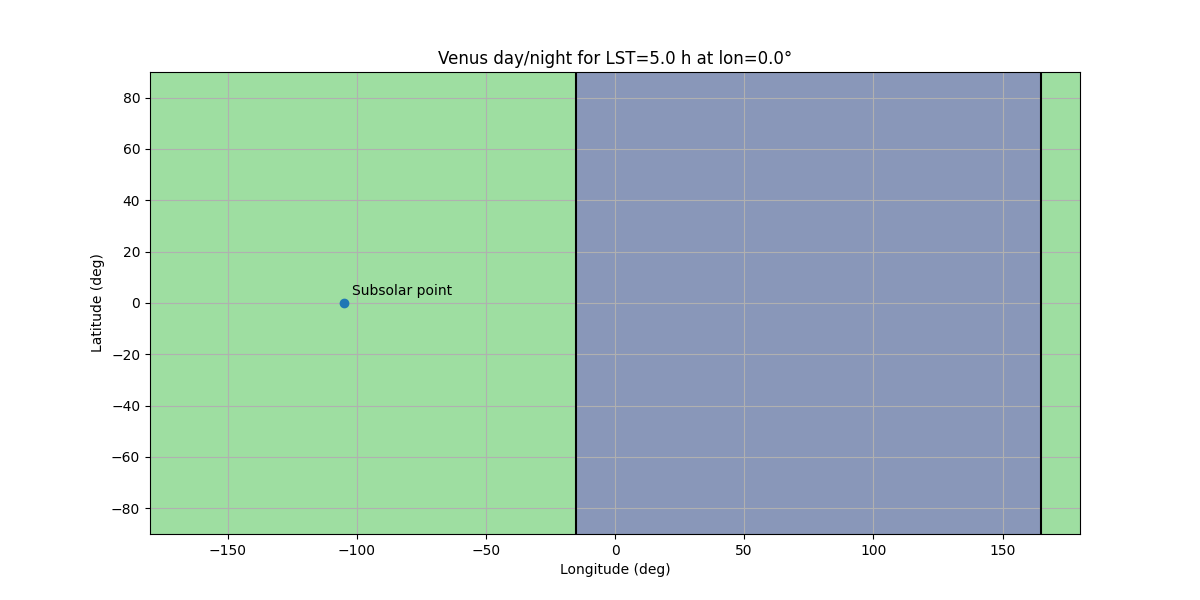

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# User inputs
# ----------------------------
lst_hours = 5.0          # local solar time you want at ref_lon
ref_lon = 0.0             # longitude where lst_hours is defined
retrograde = True         # Venus
subsolar_lat = 0.0        # good approximation for Venus

# ----------------------------
# Compute subsolar longitude
# ----------------------------
if retrograde:
    # local solar time increases westward
    subsolar_lon = ref_lon + 15.0 * (lst_hours - 12.0)
else:
    # Earth-like convention
    subsolar_lon = ref_lon + 15.0 * (12.0 - lst_hours)

# wrap to [-180, 180]
subsolar_lon = ((subsolar_lon + 180) % 360) - 180

# ----------------------------
# Build lat-lon grid
# ----------------------------
lon = np.linspace(-180, 180, 721)
lat = np.linspace(-90, 90, 361)
LON, LAT = np.meshgrid(lon, lat)

# radians
lam = np.radians(LON)
phi = np.radians(LAT)
lam_s = np.radians(subsolar_lon)
phi_s = np.radians(subsolar_lat)

# solar zenith cosine
coschi = (
    np.sin(phi) * np.sin(phi_s)
    + np.cos(phi) * np.cos(phi_s) * np.cos(lam - lam_s)
)

day = coschi > 0
night = coschi < 0

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# background: day/night mask
ax.contourf(
    LON, LAT, day.astype(int),
    levels=[-0.5, 0.5, 1.5],
    alpha=0.6
)

# terminator
ax.contour(LON, LAT, coschi, levels=[0], colors='k', linewidths=1.5)

# subsolar point
ax.plot(subsolar_lon, subsolar_lat, 'o')
ax.text(subsolar_lon + 3, subsolar_lat + 3, 'Subsolar point')

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude (deg)")
ax.set_ylabel("Latitude (deg)")
ax.set_title(f"Venus day/night for LST={lst_hours:.1f} h at lon={ref_lon:.1f}°")
ax.grid(True)

plt.show()

In [ ]:
file_traj = '/projects/restricted/infrasound/data/infrasound/2026_Venus_global_TLs/'
pattern = 'trajectories_{date}_new_{freq}Hz_{Terup}s_v{ivolc}.csv'
date_default = UTCDateTime('2026-05-01')

freqs = [0.05, 0.1, 0.5]
ivolcs = [0, 1]
#Terups = [1., 5., 20., 50., 75., 100.]
Terups = np.logspace(0,2,6)

combinations = list(itertools.product(freqs, ivolcs, Terups))

#ivolc_cpt = {ivolc: ii for ii, ivolc in enumerate(ivolcs)}
trajectories = pd.DataFrame()
for freq, ivolc, Terup in combinations:
    date_loc = date_default
    file = 'dummy'
    cpt = 0
    while not os.path.exists(file) and cpt < 1:
        file = f'{file_traj}{pattern.format(date=date_loc.strftime("%Y-%m-%d"), freq=freq, Terup=Terup, ivolc=ivolc)}'
        date_loc += 3600*24
        #print(f'{file}: {os.path.exists(file)}')
        cpt += 1

    if not os.path.exists(file):
        print(f'Not exists {file}: {os.path.exists(file)}')
        continue

    trajectories_loc = pd.read_csv(file, header=[0])
    trajectories_loc = trajectories_loc.loc[trajectories_loc.ivolcano==ivolc]
    #trajectories_loc['ivolcano'] = ivolc_cpt[ivolc]
    #trajectories_loc['file'] = file
    #print(freq, ivolc, Terup, trajectories_loc.shape[0])
    trajectories = pd.concat([trajectories, trajectories_loc])

trajectories.reset_index(drop=True, inplace=True)
trajectories.sort_values(by=['freq', 'T_eruption', 'ivolcano', 'istart'], inplace=True)
trajectories.reset_index(drop=True, inplace=True)

In [48]:
trajectories

,time,proba_loc,lat,lon,snr,time_ust,isection_time,proba,freq,ivolcano,T_eruption,istart,start_lat,start_lon
0,0.000000e+00,1.640281e-02,-85.000000,0.000000,1.0,1,1,0.016403,0.05,0,1.0,0,-85.0,0.0
1,3.600000e+03,2.076586e-02,-84.985384,-10.516420,1.0,1,1,0.020766,0.05,0,1.0,0,-85.0,0.0
2,7.200000e+03,2.773079e-02,-84.931533,-21.507493,1.0,1,1,0.027731,0.05,0,1.0,0,-85.0,0.0
3,1.080000e+04,3.555785e-02,-84.850540,-31.511423,1.0,1,1,0.035558,0.05,0,1.0,0,-85.0,0.0
4,1.440000e+04,4.365775e-02,-84.740100,-41.493605,1.0,1,1,0.043658,0.05,0,1.0,0,-85.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6354271,1.553930e+07,5.345903e-07,85.009407,96.493183,5.0,13,27,0.015122,0.50,3,100.0,4,85.0,0.0
6354272,1.554290e+07,5.345903e-07,85.107389,87.487277,5.0,13,27,0.015122,0.50,3,100.0,4,85.0,0.0
6354273,1.554650e+07,5.345932e-07,85.230421,76.779530,5.0,13,27,0.015122,0.50,3,100.0,4,85.0,0.0
6354274,1.555010e+07,5.345933e-07,85.346041,66.469843,5.0,13,27,0.015122,0.50,3,100.0,4,85.0,0.0


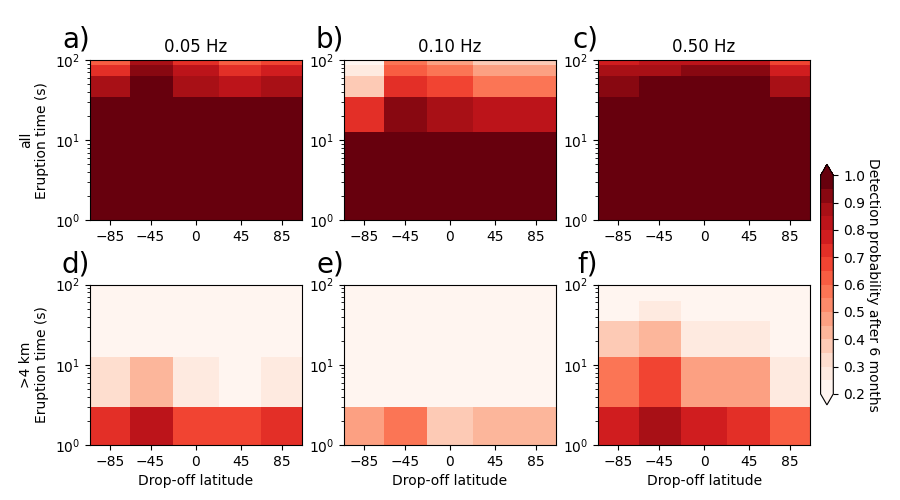

In [55]:
reload(pm)

## Make sure these options below are the ones used to create the file_traj file
start_locations=[[-85.,0.], [-45.,0.], [0.,0.], [45.,0.], [85.,0.]]

n_months = 6
snr_chosen = 2
file = f'./figures/summary_Figure_scaling_{n_months}months_TLseasonal.pdf'
#file = None
pm.plot_Figure_summary(trajectories, start_locations, n_months, snr_chosen, levels=np.arange(0.2, 1.05, 0.05), figsize=(9,5), file=file)

In [8]:
n_months = 6.
time_target = 3600*24*30*n_months
diff = abs(trajectories['time']-time_target)
trajectories_last = trajectories.loc[diff<1e4].groupby(['snr', 'freq', 'ivolcano', 'T_eruption', 'istart']).last().reset_index()

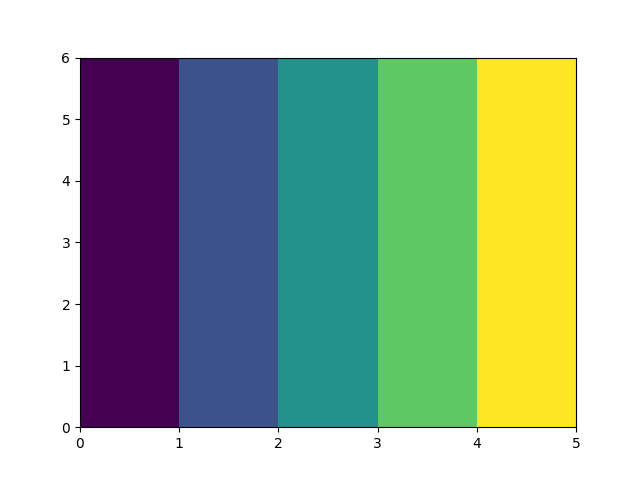

In [ ]:
snr_chosen = 2.
traj_volcano = trajectories_last.loc[(trajectories_last.snr==snr_chosen)&(trajectories_last.ivolcano==0)]
traj_volc_freq = traj_volcano.loc[traj_volcano.freq==0.05]

T_eruptions = trajectories_last.T_eruption.unique()
n_T_eruption = T_eruptions.size
n_freqs = trajectories_last.freq.unique().size
istarts = trajectories_last.istart.unique()
n_istart = istarts.size
proba_volc_freq = traj_volc_freq.proba.values.reshape((n_T_eruption, n_istart,))
#proba_volc_freq = traj_volc_freq.istart.values.reshape((n_T_eruption, n_istart,))

plt.figure()
plt.pcolormesh(proba_volc_freq)

In [21]:
traj_volc_freq

,snr,freq,ivolcano,T_eruption,istart,time,proba_loc,lat,lon,time_ust,isection_time,proba,start_lat,start_lon
0,1.0,0.05,0,1.0,0,1.555382e+07,0.016573,-85.394819,-12.526581,14,28,0.843788,-85.0,0.0
1,1.0,0.05,0,1.0,1,1.555385e+07,0.021693,-58.381267,-56.503678,14,28,0.914003,-45.0,0.0
2,1.0,0.05,0,1.0,2,1.555336e+07,0.019594,60.269739,-135.504274,14,28,0.739108,0.0,0.0
3,1.0,0.05,0,1.0,3,1.555379e+07,0.022781,59.677338,-87.504231,14,28,0.759924,45.0,0.0
4,1.0,0.05,0,1.0,4,1.555370e+07,0.018210,85.411926,60.480518,14,28,0.813177,85.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,5.0,0.05,0,100.0,0,1.555382e+07,0.003967,-85.394819,-12.526581,14,28,0.304555,-85.0,0.0
386,5.0,0.05,0,100.0,1,1.555385e+07,0.013780,-58.381267,-56.503678,14,28,0.692947,-45.0,0.0
387,5.0,0.05,0,100.0,2,1.555336e+07,0.004008,60.269739,-135.504274,14,28,0.498043,0.0,0.0
388,5.0,0.05,0,100.0,3,1.555379e+07,0.005335,59.677338,-87.504231,14,28,0.407388,45.0,0.0
